# 인급동 숏폼 vs 롱폼 비교 분석

## 1. 환경설정

In [1]:
import os
import re
import pandas as pd
from datetime import date
from dotenv import load_dotenv
from googleapiclient.discovery import build
from sqlalchemy import create_engine, text
import pymysql

load_dotenv()

api_key    = os.getenv('YOUTUBE_API_KEY')
mysql_host = os.getenv('MYSQL_HOST', 'localhost')
mysql_user = os.getenv('MYSQL_USER', 'root')
mysql_pw   = os.getenv('MYSQL_PASSWORD', '')
mysql_db   = os.getenv('MYSQL_DB', 'youtube_data')

assert api_key, '.env에 YOUTUBE_API_KEY가 없습니다.'
print(f'API KEY : {api_key[:8]}...')
print(f'MySQL   : {mysql_user}@{mysql_host}/{mysql_db}')

API KEY : AIzaSyCf...
MySQL   : root@localhost/youtube_data


## 2. Youtube 클라이언트 + DB 연결

In [2]:
# YouTube 클라이언트 초기화
youtube = build('youtube', 'v3', developerKey=api_key)
print('YouTube 클라이언트 초기화 완료')

# DB 연결
def db_connect(host, user, pw, db):
    conn = pymysql.connect(host=host, user=user, password=pw, charset='utf8mb4')
    with conn.cursor() as cur:
        cur.execute(f'CREATE DATABASE IF NOT EXISTS `{db}` CHARACTER SET utf8mb4 COLLATE utf8mb4_unicode_ci')
    conn.close()
    engine = create_engine(f'mysql+pymysql://{user}:{pw}@{host}/{db}?charset=utf8mb4')
    print('DB 연결 성공')
    return engine

engine = db_connect(mysql_host, mysql_user, mysql_pw, mysql_db)

YouTube 클라이언트 초기화 완료
DB 연결 성공


## 3. duration 파싱 + 포맷 분류 함수

In [3]:
def parse_duration(iso_duration):
    """ISO 8601 형식을 초 단위로 변환한다."""
    if not iso_duration:
        return 0
    match = re.match(r'PT(?:(\d+)H)?(?:(\d+)M)?(?:(\d+)S)?', iso_duration)
    if not match:
        return 0
    h = int(match.group(1) or 0)
    m = int(match.group(2) or 0)
    s = int(match.group(3) or 0)
    return h * 3600 + m * 60 + s

def classify_format(duration_seconds, title):
    """3분 이하 또는 #shorts 태그 = shortform, 나머지 = longform"""
    if duration_seconds <= 180 or '#shorts' in title.lower() or '#short' in title.lower():
        return 'shortform'
    return 'longform'

## 4. 인급동 수집

In [4]:
def get_trending_videos(max_results=50):
    """한국 인급동을 수집한다."""
    res = youtube.videos().list(
        part='snippet,statistics,contentDetails',
        chart='mostPopular',
        regionCode='KR',
        maxResults=max_results
    ).execute()

    video_list = []
    for item in res.get('items', []):
        title        = item['snippet']['title']
        duration_sec = parse_duration(item['contentDetails']['duration'])
        stats        = item['statistics']

        video_list.append({
            'collected_date': str(date.today()),
            'video_id':       item['id'],
            'title':          title,
            'channel':        item['snippet']['channelTitle'],
            'duration_seconds': duration_sec,
            'format_type':    classify_format(duration_sec, title),
            'view_count':     int(stats.get('viewCount', 0)),
            'like_count':     int(stats.get('likeCount', 0)),
            'comment_count':  int(stats.get('commentCount', 0)),
        })

    print(f'수집 완료: {len(video_list)}개 ({date.today()})')
    return video_list

video_list = get_trending_videos()

수집 완료: 49개 (2026-05-16)


## 5. DataFrame 정리

In [5]:
df = pd.DataFrame(video_list)

# 수치형 fillna(0)
num_cols = ['duration_seconds', 'view_count', 'like_count', 'comment_count']
for col in num_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce').fillna(0).astype(int)

# 문자형 fillna('')
str_cols = ['video_id', 'title', 'channel', 'format_type', 'collected_date']
for col in str_cols:
    df[col] = df[col].fillna('')

print('포맷 분포:')
print(df['format_type'].value_counts())
df.head(3)

포맷 분포:
format_type
longform     39
shortform    10
Name: count, dtype: int64


,collected_date,video_id,title,channel,duration_seconds,format_type,view_count,like_count,comment_count
0,2026-05-16,vMHpQH7pbjg,heaven and hell,wave to earth - Topic,269,longform,152630,3944,180
1,2026-05-16,xy4M41JVyTI,"나도 알아, 내가 변한 거 | [골드랜드] 7-8회 예고편 | 디즈니+",Disney Plus Korea 디즈니 플러스 코리아,64,shortform,34968,326,107
2,2026-05-16,alqSdyRor7c,창작의 고통,괴물쥐 유튜브,1812,longform,439121,2267,400


## 6. MySQL 저장

In [6]:
def save_to_mysql(df, engine, table='trending_videos'):
    df.to_sql(
        name=table,
        con=engine,
        if_exists='append',
        index=False,
        chunksize=500
    )
    with engine.connect() as conn:
        count = conn.execute(text(f'SELECT COUNT(*) FROM `{table}`')).scalar()
    print(f'저장 완료: {count}개 → {table}')

save_to_mysql(df, engine)

저장 완료: 99개 → trending_videos


## 7. 결과 확인 + 시각화

숏폼 비율: 20.4%
롱폼 비율: 79.6%


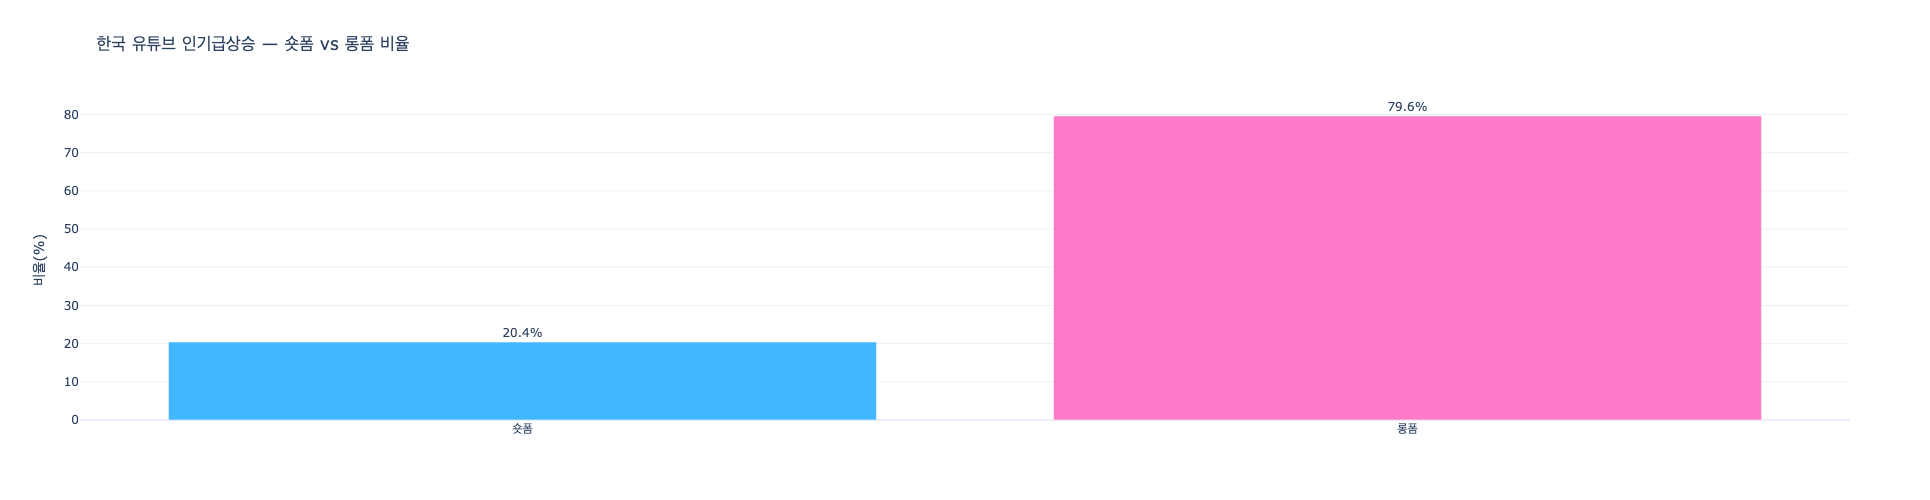

In [7]:
import plotly.graph_objects as go

# 포맷별 비율
format_counts = df['format_type'].value_counts()
shortform_ratio = round(format_counts.get('shortform', 0) / len(df) * 100, 1)
longform_ratio  = round(format_counts.get('longform', 0)  / len(df) * 100, 1)

print(f'숏폼 비율: {shortform_ratio}%')
print(f'롱폼 비율: {longform_ratio}%')

fig = go.Figure(go.Bar(
    x=['숏폼', '롱폼'],
    y=[shortform_ratio, longform_ratio],
    text=[f'{shortform_ratio}%', f'{longform_ratio}%'],
    textposition='outside',
    marker_color=['#42B6FF', '#FF7AC8']
))
fig.update_layout(
    title='한국 유튜브 인기급상승 — 숏폼 vs 롱폼 비율',
    yaxis_title='비율(%)',
    template='plotly_white',
    height=500
)
fig.show()

In [9]:
df.to_csv('/Users/jeong-eunseo/Data/teamProject/PM_dataproject/YOUTUBE_API/collectors/trend/trending_korea.csv', index=False, encoding='utf-8-sig')
print('CSV 저장 완료')

CSV 저장 완료
